In [1]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Sample dataset of emails
emails = [
    "Win a free iPhone today",
    "Call me when you have time",
    "Congratulations! You've won a lottery",
    "Meet me for lunch tomorrow",
    "Exclusive offer just for you",
    "Let's catch up over the weekend",
    "Urgent! Your account has been compromised",
    "Reminder: Your bill is due soon",
    "Get your free membership today",
    "Are we still on for the meeting?"
]

# Corresponding labels (1 for spam, 0 for not spam)
labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

# Step 1: Convert text data to numerical vectors using CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# Step 2: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42)

# Step 3: Initialize and train the Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

# Step 4: Predict on the test set
y_pred = nb_classifier.predict(X_test)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam'])

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


Accuracy: 0.6666666666666666
Classification Report:
               precision    recall  f1-score   support

    Not Spam       1.00      0.50      0.67         2
        Spam       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



## 2. Training on a Real Dataset\nNow, let's load `spam_ham_dataset.csv` to train our Naive Bayes model on a larger and more realistic set of emails.

In [19]:
# ==========================================
# Using the Real Dataset (spam_ham_dataset.csv)
# ==========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Load the dataset
df = pd.read_csv('spam_ham_dataset.csv')
print("Dataset Shape:", df.shape)
display(df.head())

# Convert labels (spam -> 1, ham -> 0)
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

# Check class distribution
print("\nClass Distribution:")
print(df['label'].value_counts())


Dataset Shape: (399, 2)


,label,message
0,ham,Happy birthday! Wishing you a wonderful year a...
1,ham,Thank you for attending today's workshop.
2,ham,Thank you for attending today's workshop.
3,spam,Exclusive deal on smartwatch. Hurry before sto...
4,spam,You have received a bonus reward of $614.



Class Distribution:
label
ham     200
spam    199
Name: count, dtype: int64


In [20]:
# Extract features and target
X_real = df['message']
y_real = df['label_num']

# Convert text to numerical vectors
vectorizer_real = CountVectorizer()
X_real_vec = vectorizer_real.fit_transform(X_real)

# Split the data
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real_vec, y_real, test_size=0.2
    
)

# Initialize and train the Naive Bayes classifier
nb_classifier_real = MultinomialNB()
nb_classifier_real.fit(X_train_real, y_train_real)

# Predict on test set
y_pred_real = nb_classifier_real.predict(X_test_real)


Accuracy on real dataset: 100.00%

Classification Report:
               precision    recall  f1-score   support

         Ham       1.00      1.00      1.00        36
        Spam       1.00      1.00      1.00        44

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



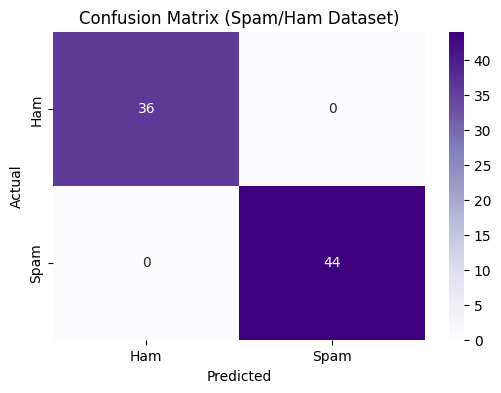

In [21]:
# Evaluate the model
accuracy_real = accuracy_score(y_test_real, y_pred_real)
report_real = classification_report(y_test_real, y_pred_real, target_names=['Ham', 'Spam'])

print(f"Accuracy on real dataset: {accuracy_real * 100:.2f}%\n")
print("Classification Report:\n", report_real)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_real, y_pred_real), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix (Spam/Ham Dataset)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
